In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata
import os

import matplotlib.pyplot as plt
import seaborn as sns

# Function

In [2]:
# https://cell2location.readthedocs.io/en/latest/notebooks/cell2location_short_demo.html
def select_slide(adata, s, s_col='sample'):
    r""" This function selects the data for one slide from the spatial anndata object.

    :param adata: Anndata object with multiple spatial experiments
    :param s: name of selected experiment
    :param s_col: column in adata.obs listing experiment name for each location
    """

    slide = adata[adata.obs[s_col].isin([s]), :]
    s_keys = list(slide.uns['spatial'].keys())
    s_spatial = np.array(s_keys)[[s in k for k in s_keys]][0]

    slide.uns['spatial'] = {s_spatial: slide.uns['spatial'][s_spatial]}

    return slide

# Read in data

In [3]:
# concatenated data
adata = sc.read_h5ad("/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025/all_b2c_cells_raw.h5ad")
adata

AnnData object with n_obs × n_vars = 269314 × 18085
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'in_tissue_manual', 'library', 'donor_section_ID', 'per-frame_donorIDs', 'donor', 'CS', 'est_CS', 'GA', 'PCW', 'section_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'spatial'
    obsm: 'spatial', 'spatial_cropped_150_buffer'

In [4]:
pd.crosstab(adata.obs['library'],adata.obs['labels_joint_source'])

labels_joint_source,primary,secondary
library,,
CellTalkHHD_Human_13_BRC2757-2758-7,65718,42313
HEA_FOET14880396,123062,38221


# Filter out low quality cells

### Plotting

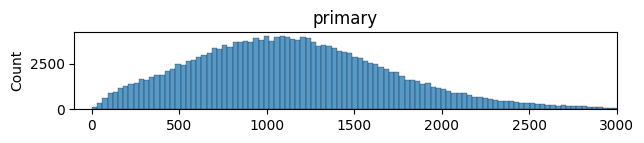

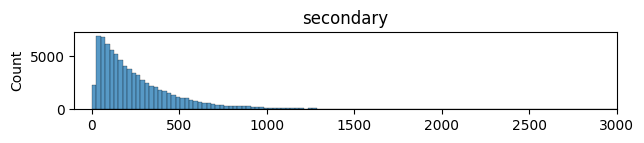

In [5]:
counts_1st = adata[adata.obs['labels_joint_source']=='primary'].obs['n_genes_by_counts'].values
plt.figure(figsize=(7, 1))
sns.histplot(counts_1st, kde=False, bins=200)
plt.title('primary')
plt.xlim(-100,3000)
plt.show()

counts_2nd = adata[adata.obs['labels_joint_source']=='secondary'].obs['n_genes_by_counts'].values
plt.figure(figsize=(7, 1))
sns.histplot(counts_2nd, kde=False, bins=200)
plt.title('secondary')
plt.xlim(-100,3000)
plt.show()

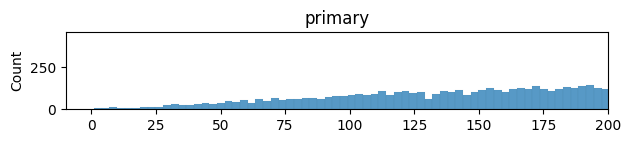

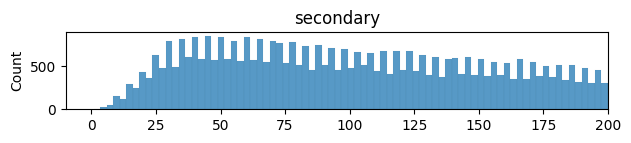

In [6]:
counts_1st = adata[adata.obs['labels_joint_source']=='primary'].obs['n_genes_by_counts'].values
plt.figure(figsize=(7, 1))
sns.histplot(counts_1st, kde=False, bins=2000)
plt.title('primary')
plt.xlim(-10,200)
plt.show()

counts_2nd = adata[adata.obs['labels_joint_source']=='secondary'].obs['n_genes_by_counts'].values
plt.figure(figsize=(7, 1))
sns.histplot(counts_2nd, kde=False, bins=2000)
plt.title('secondary')
plt.xlim(-10,200)
plt.show()

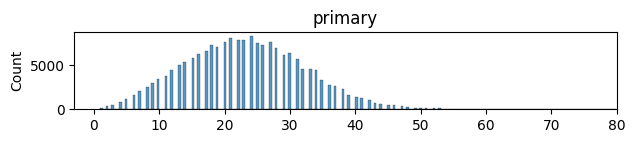

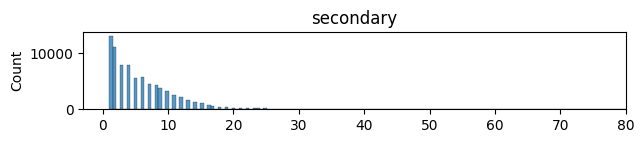

In [7]:
counts_1st = adata[adata.obs['labels_joint_source']=='primary'].obs['bin_count'].values
plt.figure(figsize=(7, 1))
sns.histplot(counts_1st, kde=False, bins=200)
plt.title('primary')
plt.xlim(-3,80)
plt.show()

counts_2nd = adata[adata.obs['labels_joint_source']=='secondary'].obs['bin_count'].values
plt.figure(figsize=(7, 1))
sns.histplot(counts_2nd, kde=False, bins=200)
plt.title('secondary')
plt.xlim(-3,80)
plt.show()

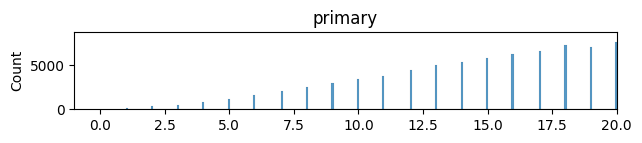

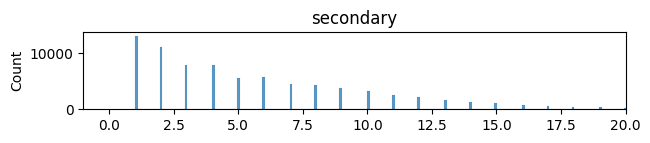

In [8]:
counts_1st = adata[adata.obs['labels_joint_source']=='primary'].obs['bin_count'].values
plt.figure(figsize=(7, 1))
sns.histplot(counts_1st, kde=False, bins=1000)
plt.title('primary')
plt.xlim(-1,20)
plt.show()

counts_2nd = adata[adata.obs['labels_joint_source']=='secondary'].obs['bin_count'].values
plt.figure(figsize=(7, 1))
sns.histplot(counts_2nd, kde=False, bins=1000)
plt.title('secondary')
plt.xlim(-1,20)
plt.show()

In [9]:
# QC metrics per library_donor
adata.obs['library_donor'] = adata.obs['library'].astype('str')+'__'+adata.obs['donor'].astype('str')
len(set(adata.obs['library_donor']))

3

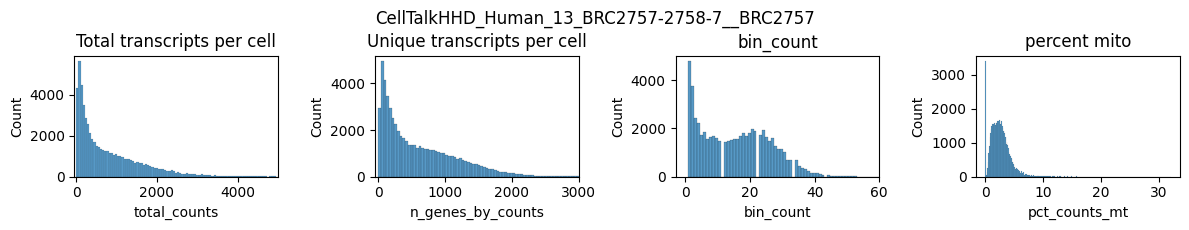

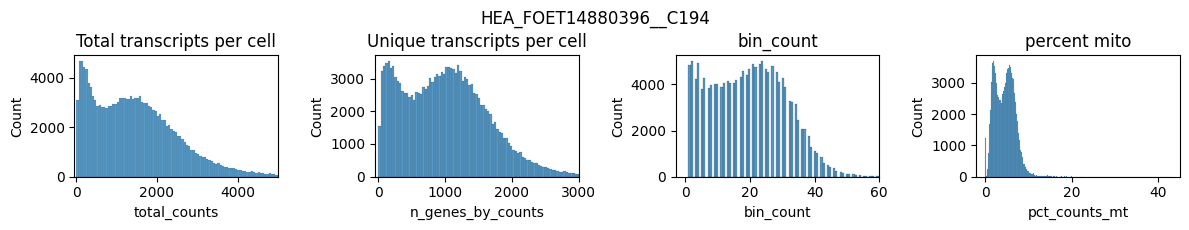

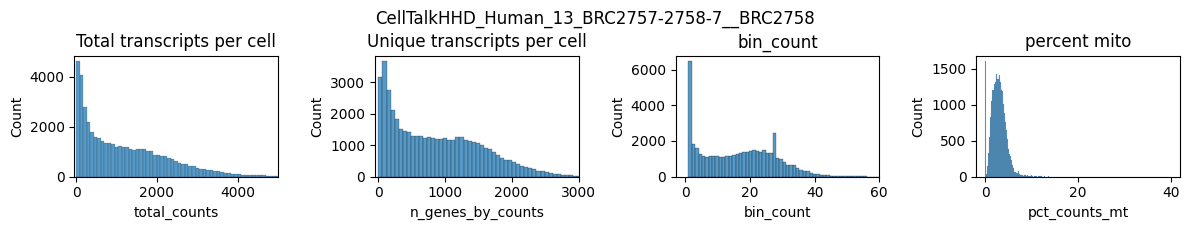

In [10]:
# QC metrics
kde = False
for library_donor in set(adata.obs['library_donor']):
    ad = adata[adata.obs['library_donor']==library_donor]
    
    fig, axs = plt.subplots(1, 4, figsize=(12, 2.5))
    axs[0].set_title("Total transcripts per cell")
    sns.histplot(
        ad.obs["total_counts"],
        kde=kde,
        ax=axs[0],
    )
    axs[0].set_xlim(-50,5000)
    axs[1].set_title("Unique transcripts per cell")
    sns.histplot(
        ad.obs["n_genes_by_counts"],
        kde=kde,
        ax=axs[1],
    )
    axs[1].set_xlim(-50,3000)
    axs[2].set_title("bin_count")
    sns.histplot(
        ad.obs["bin_count"],
        kde=kde,
        ax=axs[2],
    )
    axs[2].set_xlim(-3,60)
    axs[3].set_title("percent mito")
    sns.histplot(
        ad.obs["pct_counts_mt"],
        kde=kde,
        ax=axs[3],
    )
    # axs[3].set_xlim(-3,100)
    
    # sample_id = meta.loc[ID,'sample_id']
    # UCL_sample_id = meta.loc[ID,'UCL_sample_id']
    # fig.suptitle(f'{ID}, {sample_id}, {UCL_sample_id}', y=0.9)
    fig.suptitle(library_donor, y=0.9)
    fig.tight_layout()

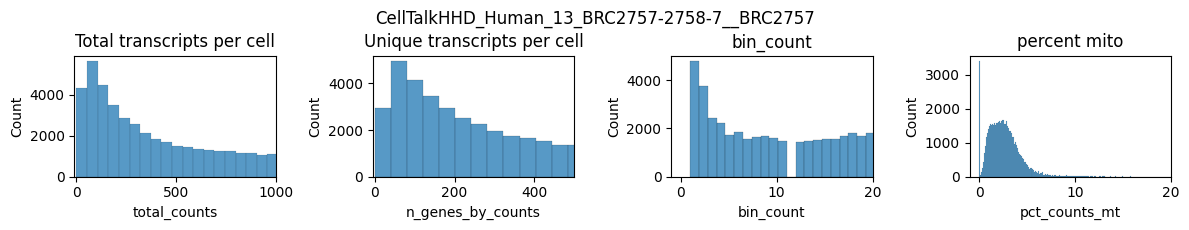

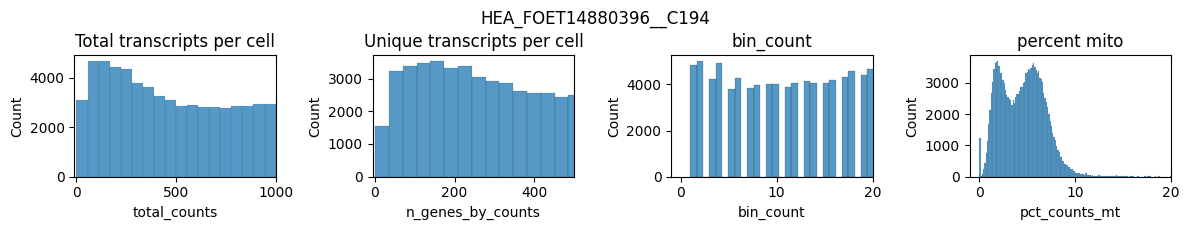

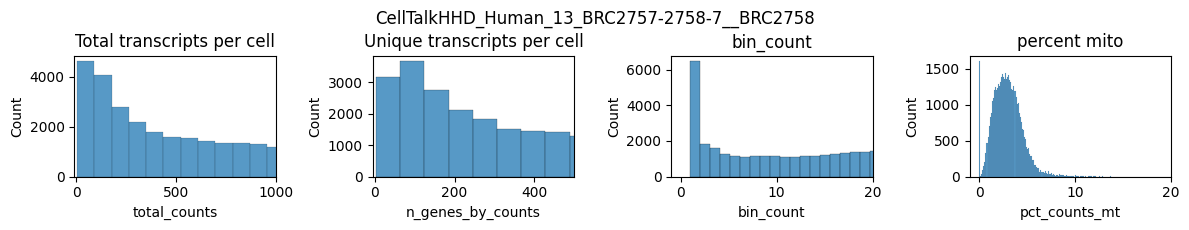

In [11]:
# QC metrics
kde = False
for library_donor in set(adata.obs['library_donor']):
    ad = adata[adata.obs['library_donor']==library_donor]
    
    fig, axs = plt.subplots(1, 4, figsize=(12, 2.5))
    axs[0].set_title("Total transcripts per cell")
    sns.histplot(
        ad.obs["total_counts"],
        kde=kde,
        ax=axs[0],
    )
    axs[0].set_xlim(-10,1000)
    axs[1].set_title("Unique transcripts per cell")
    sns.histplot(
        ad.obs["n_genes_by_counts"],
        kde=kde,
        ax=axs[1],
    )
    axs[1].set_xlim(-5,500)
    axs[2].set_title("bin_count")
    sns.histplot(
        ad.obs["bin_count"],
        kde=kde,
        ax=axs[2],
    )
    axs[2].set_xlim(-1,20)
    axs[3].set_title("percent mito")
    sns.histplot(
        ad.obs["pct_counts_mt"],
        kde=kde,
        ax=axs[3],
    )
    axs[3].set_xlim(-1,20)
    
    # sample_id = meta.loc[ID,'sample_id']
    # UCL_sample_id = meta.loc[ID,'UCL_sample_id']
    # fig.suptitle(f'{ID}, {sample_id}, {UCL_sample_id}', y=0.9)
    fig.suptitle(library_donor, y=0.9)
    fig.tight_layout()

### Filtering

In [12]:
# filtering out poor cuality cells/bins: n_genes
sc.pp.filter_cells(adata, min_genes=100)
print(f'shape of b2c: {adata.shape}')

shape of b2c: (246354, 18085)


In [13]:
# filtering out poor cuality cells/bins: bin_count (cell size)
adata = adata[adata.obs['bin_count']>=5] # remove too small cells
adata = adata[adata.obs['bin_count']<=60] # remove too large cells
print(f'shape of b2c: {adata.shape}')

shape of b2c: (225097, 18085)


In [14]:
pd.crosstab(adata.obs['library'],adata.obs['labels_joint_source'])

labels_joint_source,primary,secondary
library,,
CellTalkHHD_Human_13_BRC2757-2758-7,64246,18967
HEA_FOET14880396,121568,20316


# Save

In [15]:
adata.write("/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025/all_b2c_cells_filtered_raw.h5ad")

/home/kk837/.conda/envs/bin2cell_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


In [16]:
adata

AnnData object with n_obs × n_vars = 225097 × 18085
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'in_tissue_manual', 'library', 'donor_section_ID', 'per-frame_donorIDs', 'donor', 'CS', 'est_CS', 'GA', 'PCW', 'section_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_donor', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'spatial'
    obsm: 'spatial', 'spatial_cropped_150_buffer'

In [17]:
print(f'number of library: {len(set(adata.obs["library"]))}')
print(f'number of section: {len(set(adata.obs["section_ID"]))}')
print(f'number of donor: {len(set(adata.obs["donor"]))}')

number of library: 2
number of section: 5
number of donor: 3


In [18]:
pd.crosstab(adata.obs["section_ID"],adata.obs["donor"])

donor,BRC2757,BRC2758,C194
section_ID,,,
CellTalkHHD_Human_13_BRC2757-2758-7__BRC2757__1,21073,0,0
CellTalkHHD_Human_13_BRC2757-2758-7__BRC2757__2,24636,0,0
CellTalkHHD_Human_13_BRC2757-2758-7__BRC2758__1,0,17801,0
CellTalkHHD_Human_13_BRC2757-2758-7__BRC2758__2,0,19703,0
HEA_FOET14880396__C194__1,0,0,141884


In [19]:
df = pd.crosstab(adata.obs["section_ID"],adata.obs["donor"])
df = pd.DataFrame({'n_section':(df>0).sum()})
df_age = adata.obs[["donor","PCW","CS","est_CS"]].drop_duplicates().set_index('donor')
df[df_age.columns] = df_age.loc[df.index]
df = df.sort_values('PCW')
df

,n_section,PCW,CS,est_CS
donor,,,,
BRC2758,2,5w1d,15,16
BRC2757,2,6w3d,18,15
C194,1,9w0d,NaN,NaN


# Inspecting QC metrics

In [20]:
# adata = sc.read_h5ad("/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/CellTalkHHD/VisiumHD/bin2cell_objects/Human_Vhd-ffpe_b2c_cells_filtered_raw.h5ad",)
# adata

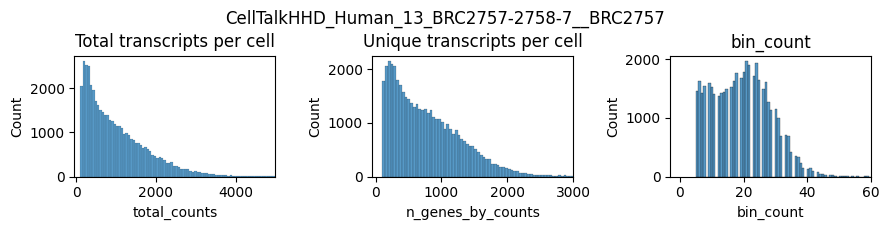

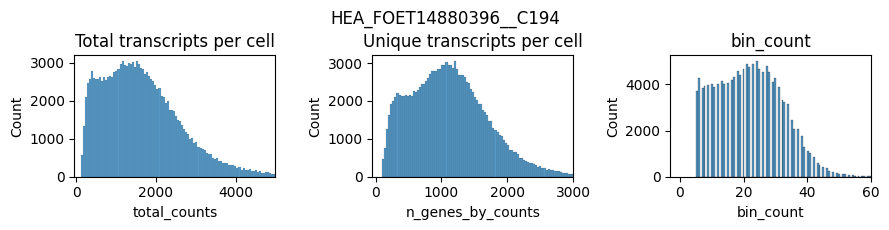

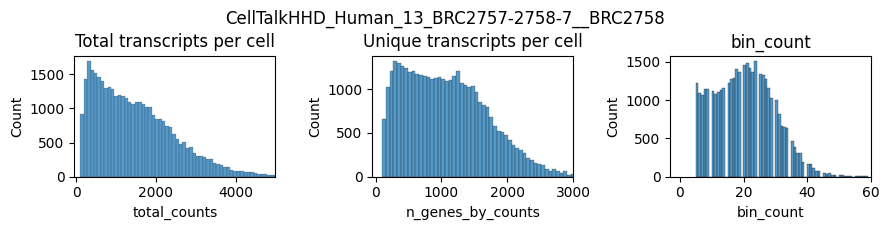

In [21]:
# QC metrics
kde = False
for library_donor in set(adata.obs['library_donor']):
    ad = adata[adata.obs['library_donor']==library_donor]
    
    fig, axs = plt.subplots(1, 3, figsize=(9, 2.5))
    axs[0].set_title("Total transcripts per cell")
    sns.histplot(
        ad.obs["total_counts"],
        kde=kde,
        ax=axs[0],
    )
    axs[0].set_xlim(-50,5000)
    axs[1].set_title("Unique transcripts per cell")
    sns.histplot(
        ad.obs["n_genes_by_counts"],
        kde=kde,
        ax=axs[1],
    )
    axs[1].set_xlim(-50,3000)
    axs[2].set_title("bin_count")
    sns.histplot(
        ad.obs["bin_count"],
        kde=kde,
        ax=axs[2],
    )
    axs[2].set_xlim(-3,60)
    
    # sample_id = meta.loc[ID,'sample_id']
    # UCL_sample_id = meta.loc[ID,'UCL_sample_id']
    # fig.suptitle(f'{ID}, {sample_id}, {UCL_sample_id}', y=0.9)
    fig.suptitle(library_donor, y=0.9)
    fig.tight_layout()

/tmp/ipykernel_733084/3524071468.py:14: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  slide.uns['spatial'] = {s_spatial: slide.uns['spatial'][s_spatial]}
/tmp/ipykernel_733084/2359701789.py:8: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide, color=["labels_joint_source"],


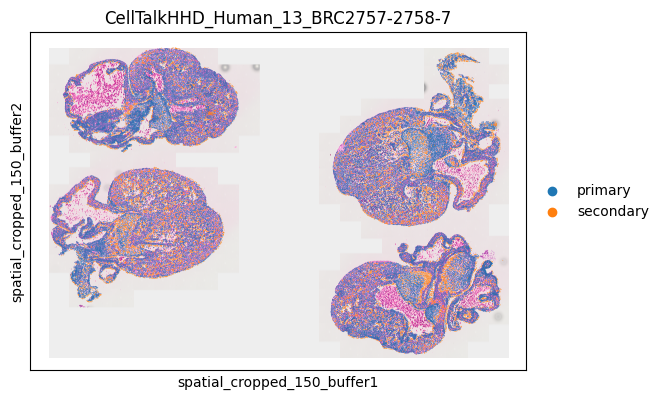

/tmp/ipykernel_733084/3524071468.py:14: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  slide.uns['spatial'] = {s_spatial: slide.uns['spatial'][s_spatial]}
/tmp/ipykernel_733084/2359701789.py:8: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide, color=["labels_joint_source"],


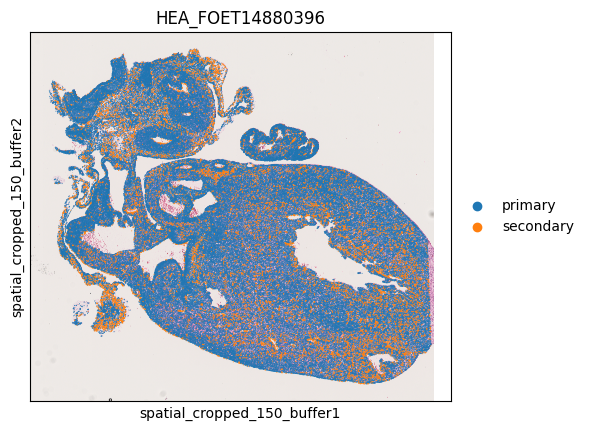

In [22]:
# plotting for inspection
sample_list = list(set(adata.obs['library']))
sample_list.sort()

for sample_id in sample_list:
    # subsetting
    slide = select_slide(adata, sample_id, s_col='library')
    sc.pl.spatial(slide, color=["labels_joint_source"], 
                  img_key="0.3_mpp_150_buffer", basis="spatial_cropped_150_buffer",
                  title=sample_id,spot_size=70)